# Exercises - Solvers

_______

We want to solve  $S(x) = Kx-F = 0$, which is linear but we don't want to use the matrix inverse.

### a) Fixed point

1. Write $S(x) = 0$ under the form $F(x) = x$
2. Try to solve the problem with a fixed point algorithm for $K = \begin{bmatrix} a, 0\\ 0, b \end{bmatrix}$ with $a,b >0$
3. Try to solve the problem with a fixed point for $K = \begin{bmatrix} a, 0\\ 0, b \end{bmatrix}$ with $a>0$ and $b<0$.
4. Interpretation?
5. Would Newton method, which is a special kind of fixed point, work on this problem?

In [7]:
import numpy as np
import matplotlib.pyplot as plt

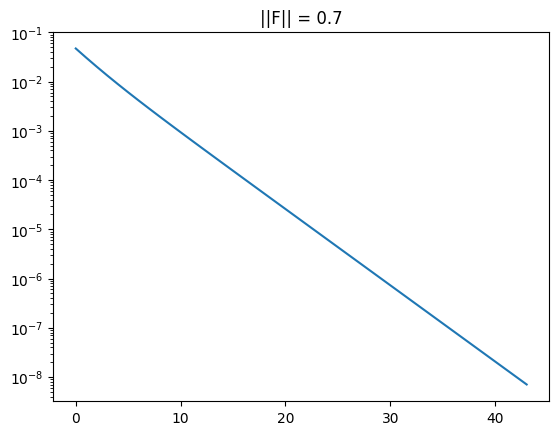

In [8]:
def fixedPoint(F, x0, maxit = 100, tol = 1e-8):
    x = [x0]
    for _ in range(maxit):
        x.append(F(x[-1]))
        if np.linalg.norm(x[-1]-x[-2]) < tol:
            break
    return x


th = np.random.rand()
R = np.array([[np.cos(th), -np.sin(th)],[np.sin(th), np.cos(th)]])

K = R @ np.array([[3,0],[0,4]]) @ R.T
f = np.random.rand(2)

S = lambda x: K @ x - f
a = 0.1
F = lambda X : X - a * S(X)
x0 = np.array([0,0])
F(x0)
x = fixedPoint(F, x0)
plt.semilogy([np.linalg.norm(x[i+1] - x[i]) for i in range(len(x)-1)])
plt.title(f"||F|| = {max(abs(np.linalg.eig(np.eye(2) - a*K)[0]))}")
plt.show()
